# NYC Taxi Trip Duration Analysis
### Python Data Analysis Project

NYC Taxi Trip Duration Analysis

1. Import Libraries
2. Load Dataset
3. Explore Dataset
4. Feature Engineering
5. Data Visualization
   - Trips by Hour
   - Trips by Day
   - Trip Duration Distribution
   - Passenger Count Analysis
   - Trip Duration vs Passenger Count
6. Handling Outliers
7. Key Insights
8. Conclusion

In [1]:
import pandas as pd 
import numpy as np

## Load Dataset
In this step we load the NYC taxi dataset using pandas.

In [6]:
df = pd.read_csv('NYC.csv') # we load the data in df variable 

In [8]:
df.head() # we got the first 5 rows 

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


## Explore Dataset
We examine the structure and statistics of the dataset.

In [11]:
df.shape # here we raws,columns numbers

(1458644, 11)

In [13]:
df.info # here we got details about datatypes of each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [14]:
df.describe() # this gives as basic analysis of data

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


In [15]:
df.isnull().sum() # here we got to know if any any columns had null values 

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

## Feature Engineering
In this step we create new time-based features from the pickup datetime.
This will help analyze taxi demand by hour and day.

In [21]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime']) 

In [24]:
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day'] = df['pickup_datetime'].dt.day_name()

In [26]:
hourly_trips = df['pickup_hour'].value_counts().sort_index()
hourly_trips

pickup_hour
0     53248
1     38571
2     27972
3     20895
4     15792
5     15002
6     33248
7     55600
8     67053
9     67663
10    65437
11    68476
12    71873
13    71473
14    74292
15    71811
16    64313
17    76483
18    90600
19    90308
20    84072
21    84185
22    80492
23    69785
Name: count, dtype: int64

## Data Visualization
In this section we analyze taxi demand patterns using visualizations.

In [28]:
!pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 487.8 kB/s eta 0:00:16
   -- ------------------------------------- 0.5/8.1 MB 487.8 kB/s eta 0:00:16
   ----- ---------------------------------- 1.0/8.1 MB 723.9 kB/s eta 0:00:10
   ------- -------------------------------- 1.6/8.1 MB 985.1 kB/s eta 0:00:07
   ---------- ----------------------------- 2.1/8.1 MB 1.2 MB/s eta 0:00:06
   -------------- ------------------------- 2.9/8.1 MB 1.5 MB/s eta 0:00:04
   ------------------ --------------------- 3.7/8.1 MB 1.8 MB/s eta 0:00:03
   -------------------- -------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

## Taxi Trips by Day By Hour
This visualization shows how taxi demand changes across different hours of day.

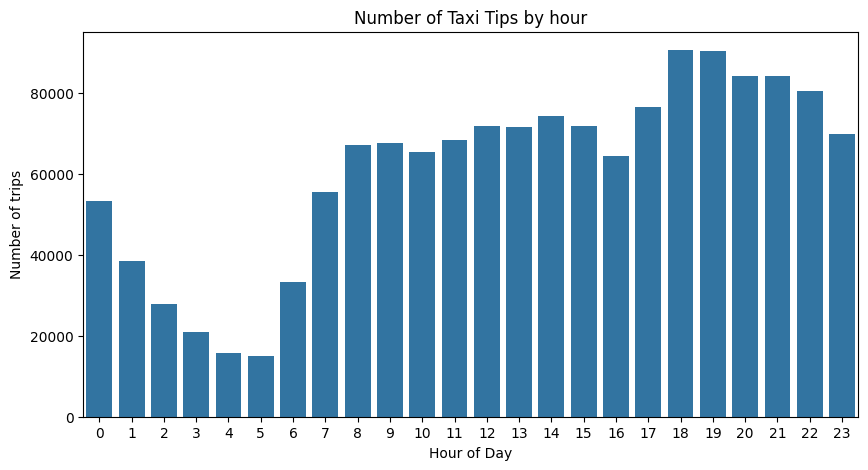

In [32]:
plt.figure(figsize=(10,5)) # it creates a canvas of width 10 and height 5

sns.barplot(x=hourly_trips.index, y = hourly_trips.values) #we use seaborn to create a bargraph

plt.title('Number of Taxi Tips by hour')  # adding a title 
plt.xlabel('Hour of Day')                 # giving name to the x axis
plt.ylabel('Number of trips')             # giving name to the y axix

plt.show()             # Displaying the chart

### Insight
Taxi demand increases during morning and evening rush hours, indicating commuting patterns in NYC.

## Taxi Trips by Day of Week
This visualization shows how taxi demand changes across different days of the week.

In [35]:
day_trips = df['pickup_day'].value_counts()
day_trips

pickup_day
Friday       223533
Saturday     220868
Thursday     218574
Wednesday    210136
Tuesday      202749
Sunday       195366
Monday       187418
Name: count, dtype: int64

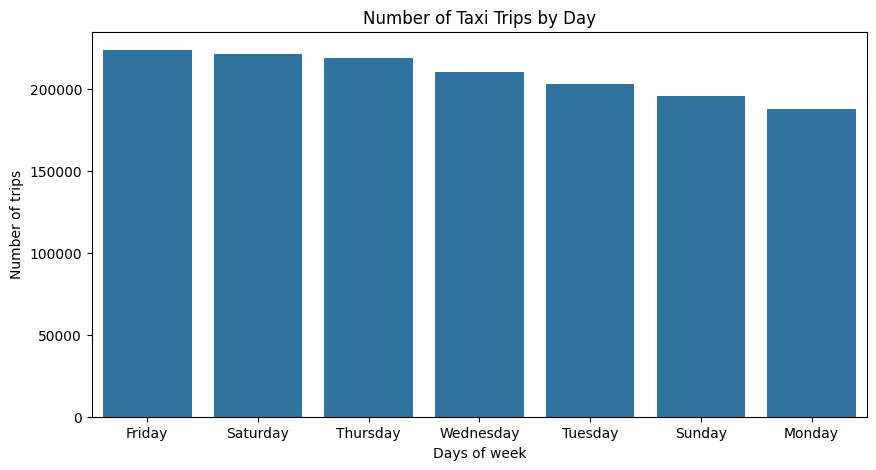

In [38]:
plt.figure(figsize=(10,5))

sns.barplot(x=day_trips.index , y= day_trips.values)

plt.title('Number of Taxi Trips by Day')
plt.xlabel('Days of week')
plt.ylabel('Number of trips')

plt.show()

### Insight
Taxi demand varies across the week. Weekdays tend to show consistent travel patterns, likely due to commuting, while weekends may show different travel behavior.

## Trip Duration Distribution
This visualization shows how taxi trip durations are distributed.

In [39]:
df['trip_duration_min'] = df['trip_duration'] / 60

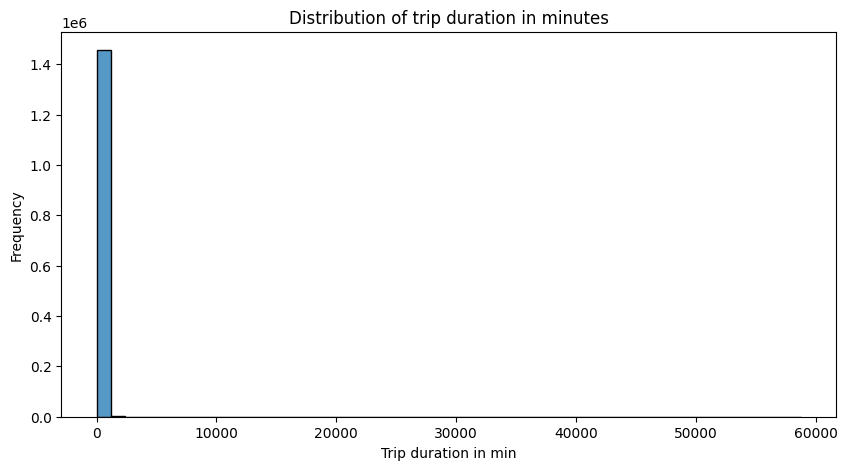

In [46]:
plt.figure(figsize=(10,5))

sns.histplot(df['trip_duration_min'], bins= 50 )

plt.title('Distribution of trip duration in minutes')
plt.xlabel('Trip duration in min')
plt.ylabel('Frequency')

plt.show()

In [42]:
df[['trip_duration','trip_duration_min']].head()

,trip_duration,trip_duration_min
0,455,7.583333
1,663,11.050000
2,2124,35.400000
3,429,7.150000
4,435,7.250000


In [45]:
df['trip_duration'].describe()

count    1.458644e+06
mean     9.594923e+02
std      5.237432e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64

## Handling Outliers
Some trips show extremely large durations (up to several days), which are unrealistic for taxi rides.
To analyze typical taxi usage, we limit the analysis to trips under 60 minutes.

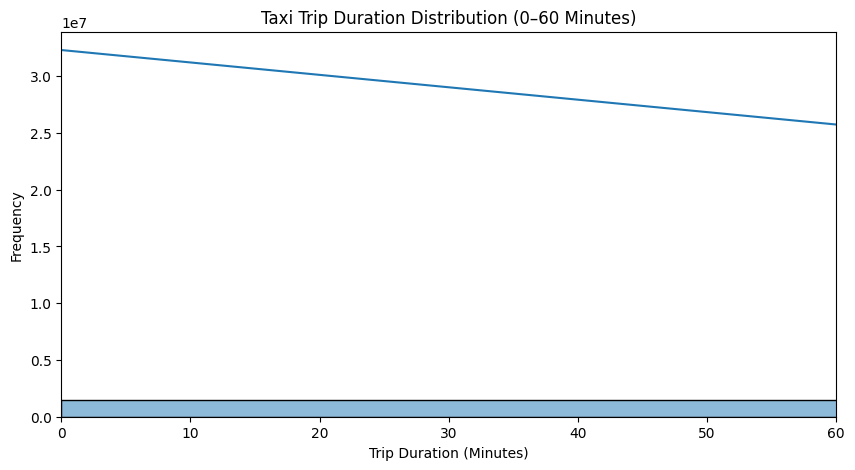

In [49]:
plt.figure(figsize=(10,5))

sns.histplot(df['trip_duration'] / 60, bins=50, kde=True)

plt.xlim(0,60)

plt.title("Taxi Trip Duration Distribution (0–60 Minutes)")
plt.xlabel("Trip Duration (Minutes)")
plt.ylabel("Frequency")

plt.show()

### Insight
Most taxi trips in NYC last between 5 and 20 minutes, suggesting that taxis are mainly used for short-distance travel within the city.

## Passenger Count Analysis
This section analyzes how many passengers usually travel in NYC taxis.

In [50]:
passenger_counts = df['passenger_count'].value_counts().sort_index()
passenger_counts

passenger_count
0         60
1    1033540
2     210318
3      59896
4      28404
5      78088
6      48333
7          3
8          1
9          1
Name: count, dtype: int64

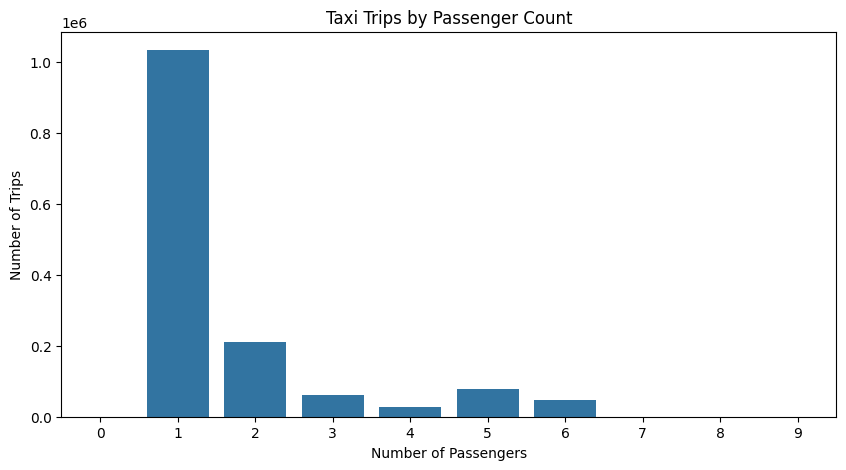

In [55]:
plt.figure(figsize=(10,5))

sns.barplot(x=passenger_counts.index, y= passenger_counts.values)


plt.title("Taxi Trips by Passenger Count")
plt.xlabel("Number of Passengers")
plt.ylabel("Number of Trips")

plt.show()

### Insight
Most taxi trips involve a single passenger, suggesting taxis are primarily used for individual travel rather than group transportation.

## Trip Duration vs Passenger Count

This analysis explores whether the number of passengers affects the duration of taxi trips.


In [60]:
avg_duration_passengers = df.groupby('passenger_count')['trip_duration'].mean() / 60
avg_duration_passengers

passenger_count
0    28.640556
1    15.506663
2    16.757639
3    17.137271
4    17.558829
5    17.837203
6    17.689254
7     0.327778
8     1.733333
9     9.333333
Name: trip_duration, dtype: float64

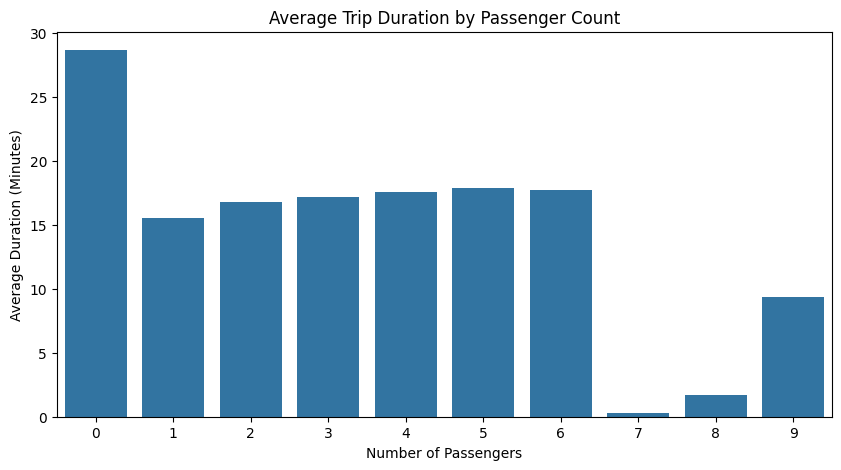

In [63]:
plt.figure(figsize=(10,5))

sns.barplot(x=avg_duration_passengers.index, y=avg_duration_passengers.values)

plt.title("Average Trip Duration by Passenger Count")
plt.xlabel("Number of Passengers")
plt.ylabel("Average Duration (Minutes)")

plt.show()

### Insight

The average trip duration does not vary significantly across passenger counts, suggesting that trip length is more influenced by travel distance and traffic conditions rather than the number of passengers.


## Key Insights

- Taxi demand peaks during typical commuting hours, particularly in the morning and evening.
- Taxi usage remains relatively consistent across weekdays, reflecting regular commuting patterns.
- Most taxi trips last between approximately 5 and 20 minutes, indicating that taxis are mainly used for short-distance travel.
- The majority of taxi rides involve a single passenger, suggesting individual travel is the most common use case.
- Trip duration does not significantly change with the number of passengers, indicating that distance and traffic conditions are the primary factors influencing travel time.


## Conclusion

This analysis explored New York City taxi trip data using Python. By performing data exploration, feature engineering, and visualization, we identified key travel patterns such as peak demand hours, common trip durations, and passenger behavior. These insights help illustrate how taxi services are primarily used for short urban trips and daily commuting.
